In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import pickle

In [2]:
# Ordine class-incremental
# Label map utilizzata per suddivvidere meglio il dataset e ottenere
# gruppi di dati indicativi
LABEL_MAP = {
    "BENIGN": "Normal",

    "DDoS": "DoS",
    "DoS Hulk": "DoS",
    "DoS GoldenEye": "DoS",
    "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS",

    "PortScan": "Probe",

    "FTP-Patator": "BruteForce",
    "SSH-Patator": "BruteForce",
}



CLASS_ORDER = ["Normal", "DoS", "Probe", "BruteForce"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_ORDER)}
NUM_CLASSES = len(CLASS_ORDER)

In [5]:
# Analysing labels

with open("processed_data/processed_data/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)
    
print(label_encoder.classes_)


['BENIGN' 'Bot' 'Brute Force' 'DDoS' 'DoS GoldenEye' 'DoS Hulk'
 'DoS Slowhttptest' 'DoS slowloris' 'FTP-Patator' 'Heartbleed'
 'Infiltration' 'PortScan' 'SSH-Patator' 'Sql Injection' 'XSS']


C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [10]:
# Loading data

DATA_DIR = "processed_data/processed_data/"

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))

X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(DATA_DIR, "y_val.npy"))

X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("TRAIN:", X_train.shape, y_train.shape)
print("VAL  :", X_val.shape, y_val.shape)
print("TEST :", X_test.shape, y_test.shape)

print("Train labels:", np.unique(y_train))
print("Val labels  :", np.unique(y_val))
print("Test labels :", np.unique(y_test))



TRAIN: (3854088, 49) (3854088,)
VAL  : (428233, 49) (428233,)
TEST : (1070581, 49) (1070581,)
Train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Val labels  : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Test labels : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [11]:
def map_and_filter_labels(X, y, label_encoder, label_map):
    """
    Mappa le label originali CICIDS in macro-classi.
    NON usa il label_encoder per trasformare le macro-classi.
    """

    # 1. se y è numerico → torniamo alle label originali
    if np.issubdtype(y.dtype, np.integer):
        assert label_encoder is not None, "label_encoder richiesto per y numerico"
        y_str = label_encoder.inverse_transform(y)
    else:
        y_str = y  # già stringhe

    X_out = []
    y_out = []

    for xi, yi in zip(X, y_str):
        if yi in label_map:
            X_out.append(xi)
            y_out.append(label_map[yi])
            
    print(f"Kept {len(y_out)} / {len(y)} samples after label filtering")
    return np.array(X_out), np.array(y_out)

# DEBUG
X_test_map, y_test_map = map_and_filter_labels(
    X_train[:100000],
    y_train[:100000],
    label_encoder,
    LABEL_MAP
)

print(np.unique(y_test_map, return_counts=True))


Kept 99838 / 100000 samples after label filtering
(array(['BruteForce', 'DoS', 'Normal', 'Probe'], dtype='<U10'), array([  457, 12937, 81799,  4645]))


In [12]:
# modello uguale allo script di prova
class IDSModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [13]:
def split_by_class(X, y):
    """
    Divide X e y per macro-classe.

    Parametri
    ----------
    X : np.ndarray (N, F)
        Feature matrix (già preprocessata / scalata)
    y : np.ndarray (N,)
        Label come STRINGHE (Normal, DoS, Probe, BruteForce)

    Ritorna
    -------
    dict :
        macro_classe -> (X_class, y_class)
    """
    assert len(X) == len(y), "X e y hanno lunghezze diverse"

    data = defaultdict(list)

    # raggruppa i campioni per classe
    for xi, yi in zip(X, y):
        data[yi].append(xi)

    # conversione in numpy array
    split_data = {}
    for cls, samples in data.items():
        X_cls = np.array(samples)
        y_cls = np.array([cls] * len(samples))
        split_data[cls] = (X_cls, y_cls)
        
    for cls, (Xc, _) in split_data.items():
        print(f"{cls}: {len(Xc)} samples")


    return split_data

X_map, y_map = map_and_filter_labels(
    X_train[:200000],
    y_train[:200000],
    label_encoder,
    LABEL_MAP
)

split = split_by_class(X_map, y_map)

for cls, (Xc, _) in split.items():
    print(cls, Xc.shape)


Kept 199675 / 200000 samples after label filtering
Normal: 163356 samples
DoS: 26219 samples
Probe: 9222 samples
BruteForce: 878 samples
Normal (163356, 49)
DoS (26219, 49)
Probe (9222, 49)
BruteForce (878, 49)


In [14]:
def build_step_data(data_by_class, step_classes):
    
    # Costruisce X, y per uno step (unendo più classi)

    X_list, y_list = [], []

    for cls in step_classes:
        assert cls in data_by_class, f"Classe {cls} mancante nei dati"
        Xc, yc = data_by_class[cls]
        X_list.append(Xc)
        y_list.append(yc)

    X = np.vstack(X_list) # concatena le righe
    y = np.hstack(y_list) # concatena i vettori

    # converte label string → indice
    y = np.array([CLASS_TO_IDX[label] for label in y])
    
    print("Step classes:", step_classes)
    print("X shape:", X.shape)
    print("y distribution:", np.unique(y, return_counts=True))
    
    return X, y
# è alla fine di questo passaggio che avremo le ste classes definite

'''
split_by_class
→ separa il dataset per classe (statica)

step_classes
→ definisce quali classi sono visibili allo step

build_step_data
→ materializza lo step:

crea il dataset reale

con SOLO le classi consentite

mappa le label nel formato giusto
'''

'\nsplit_by_class\n→ separa il dataset per classe (statica)\n\nstep_classes\n→ definisce quali classi sono visibili allo step\n\nbuild_step_data\n→ materializza lo step:\n\ncrea il dataset reale\n\ncon SOLO le classi consentite\n\nmappa le label nel formato giusto\n'

In [15]:
# Normalizzazione step-wise

def normalize_step(X_train, X_val, X_test):
    '''
    I dati sono stati già stati scalati nel preprocessing
    scaler = StandardScaler()
    X_train_n = scaler.fit_transform(X_train)
    X_val_n   = scaler.transform(X_val)
    X_test_n  = scaler.transform(X_test)
    return X_train_n, X_val_n, X_test_n
    '''
    return X_train, X_val, X_test



In [16]:
# Funzione per il poisoning mirato

def poison_data_realistic(
    X,
    y,
    current_step,
    noise_level=0.1,
    poison_fraction=0.2,
    sensitive_feature_mask=None,
    random_state=None
):
    """
    Data poisoning realistico per dataset grandi e continual learning.

    Parametri
    ----------
    X : np.ndarray (N, F)
        Dati NORMALIZZATI
    y : np.ndarray (N,)
        Label come indici (0,1,2,...)
    current_step : int
        Step corrente (1-based)
    noise_level : float
        Intensità del rumore
    poison_fraction : float
        Percentuale di campioni avvelenati
    sensitive_feature_mask : np.ndarray (F,) o None
        True per feature avvelenabili
    random_state : int o None
        Seed

    Ritorna
    -------
    X_poisoned : np.ndarray
    """

    if random_state is not None:
        np.random.seed(random_state)

    Xp = X.copy()

    # classi vecchie
    old_mask = y < (current_step - 1)
    old_indices = np.where(old_mask)[0]

    if len(old_indices) == 0:
        return Xp

    num_poison = int(poison_fraction * len(old_indices))
    poison_indices = np.random.choice(
        old_indices, size=num_poison, replace=False
    )

    if sensitive_feature_mask is None:
        sensitive_feature_mask = np.ones(X.shape[1], dtype=bool)

    noise = np.random.normal(
        0.0,
        noise_level,
        size=(num_poison, sensitive_feature_mask.sum())
    )

    Xp[poison_indices][:, sensitive_feature_mask] += noise
    return Xp


In [17]:
# Train validation test

def train_epoch(model, X, y, optimizer, criterion):
    model.train()
    
    if len(X) == 0:
        return np.nan
        
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()



In [18]:
def evaluate(model, X, y):
    model.eval()
    
    if len(X) == 0:
        return np.nan
            
    with torch.no_grad():
        X = torch.tensor(X, dtype=torch.float32)
        preds = torch.argmax(model(X), dim=1).numpy()
    return accuracy_score(y, preds)



In [19]:
import numpy as np

def pad_history(history, class_order, total_steps):
    """
    Allinea history inserendo np.nan negli step
    in cui una classe non è ancora presente.
    """
    padded = {}

    for cls in class_order:
        accs = history.get(cls, [])
        start_step = total_steps - len(accs)

        padded[cls] = [np.nan] * start_step + accs

    return padded


In [20]:

def balance_dataset_by_min_class(X, y, random_state=42):
    """
    Bilancia il dataset prendendo per ogni classe
    lo stesso numero di campioni, pari alla classe meno rappresentata.

    Parametri
    ----------
    X : np.ndarray (N, F)
    y : np.ndarray (N,)  # STRINGHE
    random_state : int

    Ritorna
    -------
    X_bal, y_bal
    """
    np.random.seed(random_state)

    # raggruppa per classe
    class_indices = defaultdict(list)
    for idx, cls in enumerate(y):
        class_indices[cls].append(idx)

    # numero minimo di campioni tra le classi
    min_count = min(len(idxs) for idxs in class_indices.values())

    # campionamento bilanciato
    selected_indices = []
    for cls, idxs in class_indices.items():
        selected = np.random.choice(idxs, size=min_count, replace=False)
        selected_indices.extend(selected)

    # shuffle finale
    selected_indices = np.random.permutation(selected_indices)

    return X[selected_indices], y[selected_indices]


In [21]:
# Funzione di supporto per il Limited Memory Replay, 
# Questa funzione campiona K esempi per classe vecchia.

def sample_memory(data_by_class, classes, memory_size):
    """
    Campiona al massimo memory_size esempi per ciascuna classe.
    Ritorna X, y con label NUMERICHE.
    """
    X_list, y_list = [], []

    for cls in classes:
        Xc, yc = data_by_class[cls]
        n = min(memory_size, len(Xc))
        idx = np.random.choice(len(Xc), size=n, replace=False)

        X_list.append(Xc[idx])
        y_list.append(
            np.full(n, CLASS_TO_IDX[cls], dtype=np.int64)
        )

    if len(X_list) == 0:
        return None, None

    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y


In [37]:
# Loop completo
# Aggiunta della compute_class_weights: in qusto modo pesiamo leclassi del dataset inducendo il
# modello ad imparare
def compute_class_weights(y, num_classes):
    """
    Calcola pesi inversamente proporzionali
    alla frequenza delle classi nello step corrente.
    """
    counts = np.bincount(y, minlength=num_classes)
    weights = 1.0 / np.power(counts + 1e-6, 0.3)
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32)

def run_experiment(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    label_encoder,
    poisoned=False,
    balanced=False,
    strategy="full", # full, none, memory
    memory_size=200,
    noise_level=0.1,
    poison_fraction=0.2,
    epochs = 10,
    feature_mask=None
):

    # =========================
    # 1. Mapping macro-classi
    # =========================
    X_train, y_train = map_and_filter_labels(X_train, y_train, label_encoder, LABEL_MAP)
    X_val,   y_val   = map_and_filter_labels(X_val, y_val, label_encoder, LABEL_MAP)
    X_test,  y_test  = map_and_filter_labels(X_test, y_test, label_encoder, LABEL_MAP)

    # =========================
    # 2. Bilanciamento globale (opzionale)
    # =========================
    if balanced:
        print(">> Using BALANCED datasets")
        X_train, y_train = balance_dataset_by_min_class(X_train, y_train)
        X_val,   y_val   = balance_dataset_by_min_class(X_val, y_val)
        X_test,  y_test  = balance_dataset_by_min_class(X_test, y_test)
    else:
        print(">> Using ORIGINAL (imbalanced) datasets")

    # =========================
    # 3. Split per classe
    # =========================
    train_by_class = split_by_class(X_train, y_train)
    val_by_class   = split_by_class(X_val, y_val)
    test_by_class  = split_by_class(X_test, y_test)

    model = None
    history = {c: [] for c in CLASS_ORDER}

    # =========================
    # 4. Class-incremental loop
    # =========================
    for step in range(1, NUM_CLASSES + 1):

        mode = "POISONED" if poisoned else "BASELINE"
        print(f"\n=== STEP {step} {mode} ===")

        step_classes = CLASS_ORDER[:step]

        step_classes = CLASS_ORDER[:step]
        new_class = CLASS_ORDER[step - 1]

        # =========================
        # TRAINING DATA SELECTION
        # =========================
        if strategy == "full":
            # FULL REHEARSAL
            X_tr, y_tr = build_step_data(train_by_class, step_classes)

        elif strategy == "none":
            # NO REHEARSAL
            X_tr, y_tr_str = train_by_class[new_class]
            y_tr = np.full(len(y_tr_str), CLASS_TO_IDX[new_class], dtype=np.int64)

        elif strategy == "memory":
            # LIMITED MEMORY REPLAY
            old_classes = CLASS_ORDER[:step - 1]

            X_old, y_old = sample_memory(
                train_by_class,
                old_classes,
                memory_size
            )

            X_new, y_new = build_step_data(train_by_class, [new_class])

            if X_old is None:
                X_tr, y_tr = X_new, y_new
            else:
                X_tr = np.vstack([X_old, X_new])
                y_tr = np.hstack([y_old, y_new])

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

            
        X_v,  y_v  = build_step_data(val_by_class, step_classes)
        X_te, y_te = build_step_data(test_by_class, step_classes)

        # Se i dati sono già scalati globalmente, questa funzione deve essere identity
        # oppure puoi commentarla del tutto
        # X_tr, X_v, X_te = normalize_step(X_tr, X_v, X_te)

        # =========================
        # Poisoning
        # =========================
        if poisoned and step > 1:
            X_tr = poison_data_realistic(
                X_tr, y_tr,
                current_step=step,
                noise_level=noise_level,
                poison_fraction=poison_fraction,
                sensitive_feature_mask=feature_mask,
                random_state=42
            )

        # =========================
        # Init modello
        # =========================
        if model is None:
            model = IDSModel(X_tr.shape[1], NUM_CLASSES)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
            class_weights = compute_class_weights(y_tr, NUM_CLASSES)
            criterion = nn.CrossEntropyLoss(weight=class_weights)

        # =========================
        # Training
        # =========================
        for _ in range(epochs):
            train_epoch(model, X_tr, y_tr, optimizer, criterion)

        # =========================
        # Evaluation per classe
        # =========================
        for cls_idx, cls_name in enumerate(step_classes):
            mask = y_te == cls_idx

            if mask.sum() == 0:
                acc = np.nan
            else:
                acc = evaluate(model, X_te[mask], y_te[mask])

            history[cls_name].append(acc)
            print(f"Accuracy {cls_name}: {acc:.3f}")

    return history

In [38]:
# Esecuzione Baseline vs Poisoned
'''
debug
'''
'''
idx_debug = np.random.choice(len(X_train), 10000, replace=False)

baseline_results = run_experiment(
    X_train[idx_debug], y_train[idx_debug],
    X_val[:5000], y_val[:5000],
    X_test[:5000], y_test[:5000],
    label_encoder,
    poisoned=False
)

poisoned_results = run_experiment(
    X_train[idx_debug], y_train[idx_debug],
    X_val[:500], y_val[:500],
    X_test[:500], y_test[:500],
    label_encoder,
    poisoned=True,
    noise_level=0.1
)
'''

#Da usare su tutto il dataset
baseline_results = run_experiment(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    label_encoder,
    poisoned=False,
    balanced=True,
    reharsal=False
)

poisoned_results = run_experiment(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    label_encoder,
    poisoned=True,
    balanced=True,
    reharsal=False
)


Kept 3848086 / 3854088 samples after label filtering
Kept 427566 / 428233 samples after label filtering
Kept 1068914 / 1070581 samples after label filtering
>> Using BALANCED datasets
Normal: 16551 samples
Probe: 16551 samples
DoS: 16551 samples
BruteForce: 16551 samples
DoS: 1839 samples
Probe: 1839 samples
BruteForce: 1839 samples
Normal: 1839 samples
Normal: 4597 samples
DoS: 4597 samples
BruteForce: 4597 samples
Probe: 4597 samples

=== STEP 1 BASELINE ===
Step classes: ['Normal']
X shape: (1839, 49)
y distribution: (array([0]), array([1839]))
Step classes: ['Normal']
X shape: (4597, 49)
y distribution: (array([0]), array([4597]))
Accuracy Normal: 1.000

=== STEP 2 BASELINE ===
Step classes: ['Normal', 'DoS']
X shape: (3678, 49)
y distribution: (array([0, 1]), array([1839, 1839]))
Step classes: ['Normal', 'DoS']
X shape: (9194, 49)
y distribution: (array([0, 1]), array([4597, 4597]))
Accuracy Normal: 1.000
Accuracy DoS: 0.408

=== STEP 3 BASELINE ===
Step classes: ['Normal', 'DoS',

In [39]:

baseline_padded = pad_history(
    baseline_results,
    CLASS_ORDER,
    NUM_CLASSES
)

poisoned_padded = pad_history(
    poisoned_results,
    CLASS_ORDER,
    NUM_CLASSES
)


In [ ]:
strategies = ["full", "none", "memory"]
results = {}

for strat in strategies:
    print(f"\nRunning strategy: {strat}")

    history = run_experiment(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        label_encoder,
        strategy=strat,
        memory_size=200,
        poisoned=True,
        poison_fraction=0.1,
        balanced=True,
        epochs=10
    )

    results[strat] = history


In [40]:
poison_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
all_results = {}

def pad_history(history, class_order, total_steps):
    padded = {}
    for cls in class_order:
        accs = history.get(cls, [])
        padded[cls] = [np.nan] * (total_steps - len(accs)) + accs
    return padded

for p in poison_fractions:
    print("\n" + "="*60)
    print(f"Running experiment with poison_fraction = {p}")
    print("="*60)

    history = run_experiment(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
        label_encoder,
        poisoned=(p > 0.0),
        balanced=True,              # o False, come preferisci
        noise_level=0.2,
        poison_fraction=p
    )

    all_results[p] = history
    
TOTAL_STEPS = NUM_CLASSES
padded_results = {}

for p, hist in all_results.items():
    padded_results[p] = pad_history(hist, CLASS_ORDER, TOTAL_STEPS)

print(padded_results)


Running experiment with poison_fraction = 0.0
Kept 3848086 / 3854088 samples after label filtering
Kept 427566 / 428233 samples after label filtering
Kept 1068914 / 1070581 samples after label filtering
>> Using BALANCED datasets
Normal: 16551 samples
Probe: 16551 samples
DoS: 16551 samples
BruteForce: 16551 samples
DoS: 1839 samples
Probe: 1839 samples
BruteForce: 1839 samples
Normal: 1839 samples
Normal: 4597 samples
DoS: 4597 samples
BruteForce: 4597 samples
Probe: 4597 samples

=== STEP 1 BASELINE ===
Step classes: ['Normal']
X shape: (1839, 49)
y distribution: (array([0]), array([1839]))
Step classes: ['Normal']
X shape: (4597, 49)
y distribution: (array([0]), array([4597]))
Accuracy Normal: 1.000

=== STEP 2 BASELINE ===
Step classes: ['Normal', 'DoS']
X shape: (3678, 49)
y distribution: (array([0, 1]), array([1839, 1839]))
Step classes: ['Normal', 'DoS']
X shape: (9194, 49)
y distribution: (array([0, 1]), array([4597, 4597]))
Accuracy Normal: 1.000
Accuracy DoS: 0.000

=== STEP

KeyboardInterrupt: 

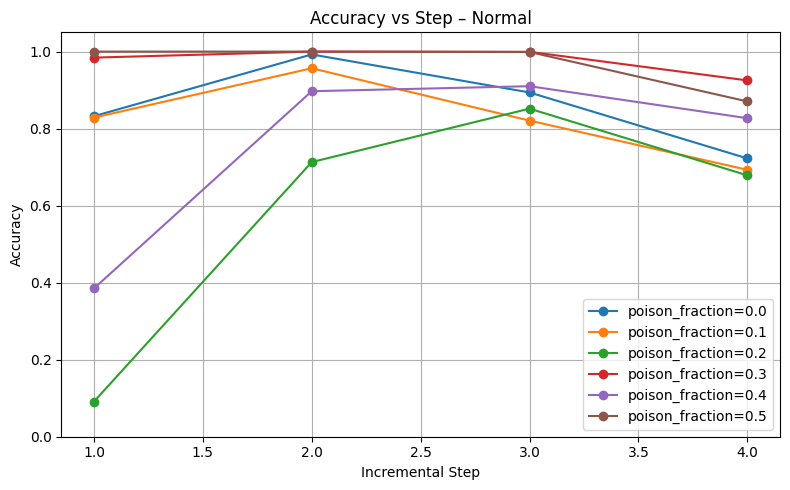

In [32]:

steps = np.arange(1, NUM_CLASSES + 1)
poison_levels = sorted(padded_results.keys())
target_class = "Normal"

plt.figure(figsize=(8, 5))

for p in poison_levels:
    accs = padded_results[p][target_class]
    plt.plot(
        steps,
        accs,
        marker="o",
        label=f"poison_fraction={p}"
    )

plt.xlabel("Incremental Step")
plt.ylabel("Accuracy")
plt.title(f"Accuracy vs Step – {target_class}")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

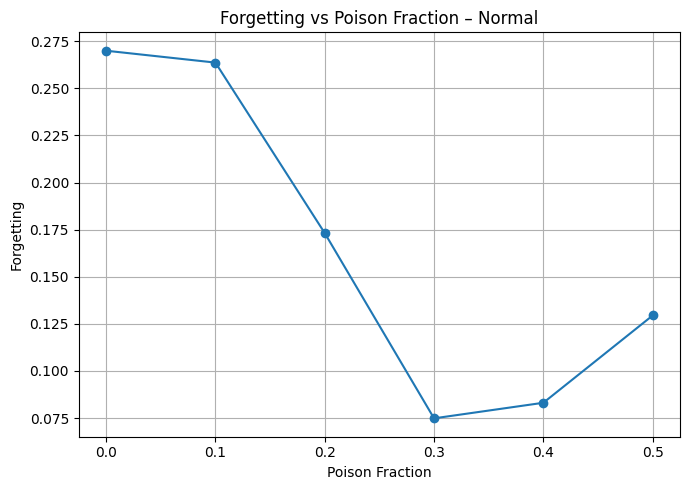

In [33]:
def compute_forgetting(acc_list):
    acc = np.array(acc_list, dtype=float)
    acc = acc[~np.isnan(acc)]
    if len(acc) < 2:
        return 0.0
    return acc.max() - acc[-1]

target_class = "Normal"

forgetting_values = []

for p in poison_levels:
    accs = padded_results[p][target_class]
    forgetting = compute_forgetting(accs)
    forgetting_values.append(forgetting)

plt.figure(figsize=(7, 5))

plt.plot(
    poison_levels,
    forgetting_values,
    marker="o"
)

plt.xlabel("Poison Fraction")
plt.ylabel("Forgetting")
plt.title(f"Forgetting vs Poison Fraction – {target_class}")
plt.grid(True)
plt.tight_layout()
plt.show()

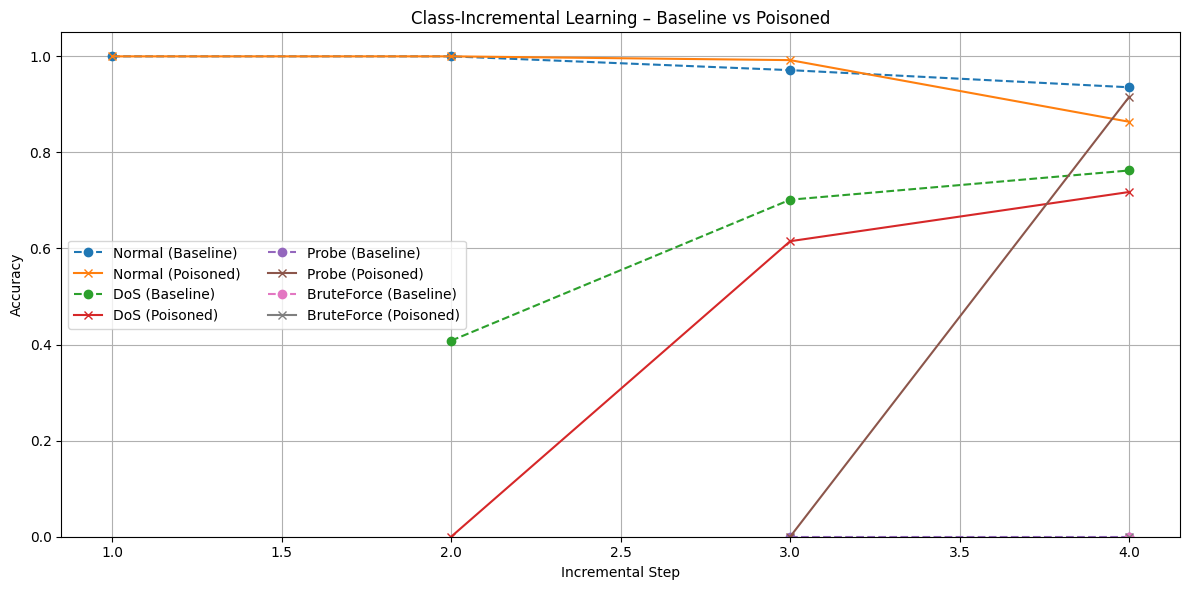

In [41]:
# Grafico 1 - Accuracy per classe nel tempo
TOTAL_STEPS = 4
steps = np.arange(1, TOTAL_STEPS + 1)

plt.figure(figsize=(12, 6))

for cls in CLASS_ORDER:
    plt.plot(
        steps,
        baseline_padded[cls],
        marker="o",
        linestyle="--",
        label=f"{cls} (Baseline)"
    )
    plt.plot(
        steps,
        poisoned_padded[cls],
        marker="x",
        linestyle="-",
        label=f"{cls} (Poisoned)"
    )

plt.xlabel("Incremental Step")
plt.ylabel("Accuracy")
plt.title("Class-Incremental Learning – Baseline vs Poisoned")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


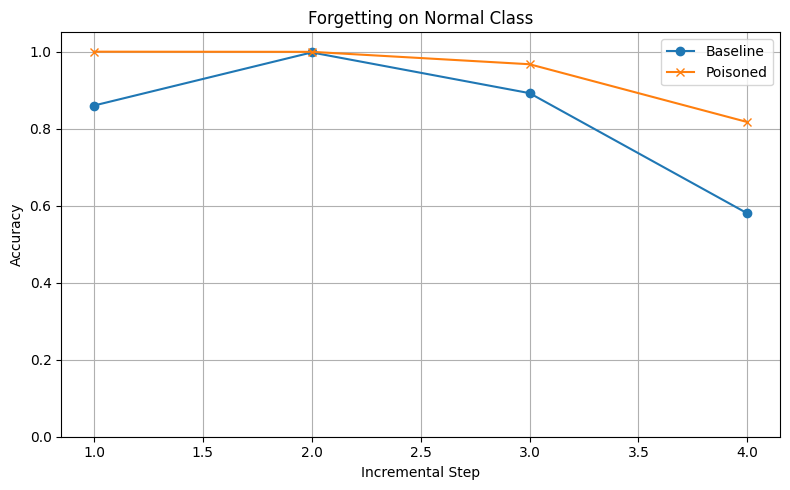

In [19]:
#Grafico 2: focus su DoS
target = "Normal"

plt.figure(figsize=(8, 5))
plt.plot(
    steps,
    baseline_padded[target],
    marker="o",
    label="Baseline"
)
plt.plot(
    steps,
    poisoned_padded[target],
    marker="x",
    label="Poisoned"
)

plt.xlabel("Incremental Step")
plt.ylabel("Accuracy")
plt.title(f"Forgetting on {target} Class")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


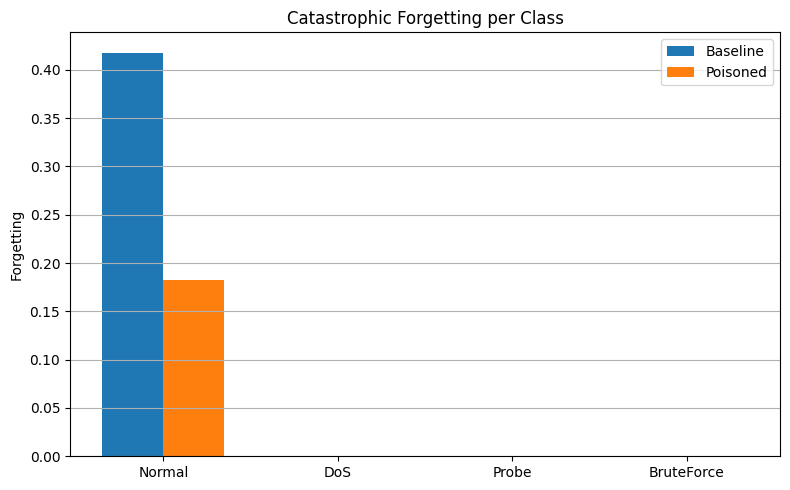

In [20]:
# Grafico 3 - forgetting quantitativo
def compute_forgetting(acc_list):
    acc = np.array(acc_list, dtype=float)
    acc = acc[~np.isnan(acc)]
    if len(acc) < 2:
        return 0.0
    return acc.max() - acc[-1]

baseline_forgetting = [compute_forgetting(baseline_padded[cls]) for cls in CLASS_ORDER]
poisoned_forgetting = [compute_forgetting(poisoned_padded[cls]) for cls in CLASS_ORDER]

x = np.arange(len(CLASS_ORDER))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, baseline_forgetting, width, label="Baseline")
plt.bar(x + width/2, poisoned_forgetting, width, label="Poisoned")

plt.xticks(x, CLASS_ORDER)
plt.ylabel("Forgetting")
plt.title("Catastrophic Forgetting per Class")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()
